# 💘 CUPIDY — Preparación de Datos
## Proyecto CRISP-DM | Speed Dating Experiment — Columbia University

**Objetivo:** Predecir si dos personas tendrán match mutuo,
usando únicamente perfil del participante

**Dataset:** Speed Dating Experiment — 8.378 observaciones, 195 variables originales  
**Variable objetivo:** `match` (binaria: 1=match mutuo, 0=no match)   
**Metodología:** CRISP-DM (Cross Industry Standard Process for Data Mining)

In [1]:
import matplotlib
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
PALETTE = {"primario": "#FF1493", "secundario": "#FFB6C1", "negativo": "#FF6B6B"}
print("Librerías cargadas")

Librerías cargadas


## FASE 1 — ENTENDIMIENTO DEL NEGOCIO

### 1.1 Contexto
El experimento de speed dating de Columbia University (2002–2004) reunió a estudiantes
de posgrado en 21 oleadas de eventos. Cada participante tuvo entre 10 y 20 mini-citas
de 4 minutos. Al final de cada cita, marcaba YES o NO. Si ambos marcaban YES → match.

### 1.2 Problema de negocio
Apps de citas que necesitan predecir compatibilidad
**antes** de que las personas se conozcan, usando solo el perfil.

### 1.3 Objetivo de minería
Construir un modelo de clasificación binaria que prediga `match` (1/0) usando
variables del perfil del participante recopiladas en el registro.

### 1.4 Diseño de solución
| Elemento | Detalle |
|---|---|
| Tipo de problema | Clasificación binaria supervisada |
| Variable objetivo | match (0=No, 1=Sí) |
| Métodos | DT, MLP, SVM, KNN, RF, XGBoost, GradientBoosting |
| Evaluación principal | ROC-AUC (métrica correcta para clases desbalanceadas) |
| Línea base | ROC-AUC = 0.5 (clasificador aleatorio) |
| Meta | ROC-AUC > 0.75 en test set |

## FASE 2 — ENTENDIMIENTO DE LOS DATOS

### 2.1 Carga y exploración inicial

In [2]:
df = pd.read_csv("../data/Speed Dating Data.csv", encoding="latin-1")
print(f"Shape original: {df.shape}")
print(f"Columnas: {df.shape[1]}")
print(f"Filas: {df.shape[0]:,}")
print(f"\nPrimeras columnas: {df.columns[:10].tolist()}")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())
df.head(3)

Shape original: (8378, 82)
Columnas: 82
Filas: 8,378

Primeras columnas: ['iid', 'id', 'idg', 'partner', 'pid', 'wave', 'round', 'position', 'positin1', 'order']

Tipos de datos:
int64      77
object      4
float64     1
Name: count, dtype: int64


,iid,id,idg,partner,pid,wave,round,position,positin1,order,...,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,match
0,1,3,224,249,66,2,11,7,5,3,...,3,2,3,6,2,9,9,3,7,0
1,2,191,46,166,146,19,10,12,19,10,...,4,9,7,6,9,7,2,9,10,0
2,3,401,224,215,16,21,2,6,19,9,...,9,6,6,8,10,8,7,7,8,0


### 2.2 Ciclo de vida de los datos
- **Generación:** Formularios físicos en eventos de speed dating (2002–2004), Columbia University
- **Momentos de captura:**
  - **Time 1 (signup):** Antes del evento — perfil, preferencias, intereses ← USAREMOS ESTAS
  - **Scorecard:** Durante cada cita — ratings mutuos
  - **Time 2/3 (followup):** Días después 
- **Almacenamiento:** CSV con 195 columnas, digitalizado desde formularios físicos
- **Periodicidad:** Histórico estático (21 waves, no se actualiza)

### 2.3 Diccionario de variables seleccionadas

In [3]:
diccionario = pd.DataFrame([
    ("gender","Género del participante","Binaria","0=Mujer, 1=Hombre","Time 1"),
    ("age","Edad del participante","Numérica","18–45","Time 1"),
    ("age_o","Edad de la pareja","Numérica","18–45","Time 1"),
    ("race","Raza del participante","Categórica","1=Negro,2=Caucásico,3=Latino,4=Asiático,6=Otro","Time 1"),
    ("race_o","Raza de la pareja","Categórica","1-6","Time 1"),
    ("samerace","Misma raza que la pareja","Binaria","0=No, 1=Sí","Time 1"),
    ("imprace","Importancia de misma raza en pareja ideal","Ordinal","1–10","Time 1"),
    ("imprelig","Importancia de misma religión en pareja","Ordinal","1–10","Time 1"),
    ("goal","Objetivo en el evento","Categórica","1=Diversión…6=Otro","Time 1"),
    ("date","Frecuencia de citas en general","Ordinal","1=Varias/sem…7=Nunca","Time 1"),
    ("go_out","Frecuencia de salidas sociales","Ordinal","1=Varias/sem…7=Nunca","Time 1"),
    ("field_cd","Área de estudio codificada","Categórica","1=Derecho…18=Otro","Time 1"),
    ("career_c","Carrera esperada codificada","Categórica","1=Abogado…17=Arquitecto","Time 1"),
    ("income","Ingreso mediano del código postal","Numérica",">0","Time 1"),
    ("mn_sat","SAT mediano de su universidad (proxy IQ)","Numérica",">0","Time 1"),
    ("tuition","Matrícula de su universidad","Numérica",">0","Time 1"),
    ("exphappy","Felicidad esperada en el evento","Ordinal","1–10","Time 1"),
    ("expnum","Personas que espera que le gusten","Numérica","≥0","Time 1"),
    ("attr1_1","Importancia atractivo en pareja ideal","Numérica","0–100 o 0–10","Time 1"),
    ("sinc1_1","Importancia sinceridad en pareja ideal","Numérica","0–100 o 0–10","Time 1"),
    ("intel1_1","Importancia inteligencia en pareja ideal","Numérica","0–100 o 0–10","Time 1"),
    ("fun1_1","Importancia diversión en pareja ideal","Numérica","0–100 o 0–10","Time 1"),
    ("amb1_1","Importancia ambición en pareja ideal","Numérica","0–100 o 0–10","Time 1"),
    ("shar1_1","Importancia intereses compartidos","Numérica","0–100 o 0–10","Time 1"),
    ("attr3_1","Autopercepción de atractivo propio","Ordinal","1–10","Time 1"),
    ("sinc3_1","Autopercepción de sinceridad propia","Ordinal","1–10","Time 1"),
    ("intel3_1","Autopercepción de inteligencia propia","Ordinal","1–10","Time 1"),
    ("fun3_1","Autopercepción de diversión propia","Ordinal","1–10","Time 1"),
    ("amb3_1","Autopercepción de ambición propia","Ordinal","1–10","Time 1"),
    ("sports","Interés en practicar deportes","Ordinal","1–10","Time 1"),
    ("tvsports","Interés en ver deportes","Ordinal","1–10","Time 1"),
    ("exercise","Interés en ejercicio/gym","Ordinal","1–10","Time 1"),
    ("dining","Interés en salir a comer","Ordinal","1–10","Time 1"),
    ("museums","Interés en museos y galerías","Ordinal","1–10","Time 1"),
    ("art","Interés en arte","Ordinal","1–10","Time 1"),
    ("hiking","Interés en senderismo/camping","Ordinal","1–10","Time 1"),
    ("gaming","Interés en videojuegos","Ordinal","1–10","Time 1"),
    ("clubbing","Interés en bailar/clubes nocturnos","Ordinal","1–10","Time 1"),
    ("reading","Interés en lectura","Ordinal","1–10","Time 1"),
    ("tv","Interés en ver televisión","Ordinal","1–10","Time 1"),
    ("theater","Interés en teatro","Ordinal","1–10","Time 1"),
    ("movies","Interés en cine","Ordinal","1–10","Time 1"),
    ("concerts","Interés en conciertos","Ordinal","1–10","Time 1"),
    ("music","Interés en música","Ordinal","1–10","Time 1"),
    ("shopping","Interés en compras","Ordinal","1–10","Time 1"),
    ("yoga","Interés en yoga/meditación","Ordinal","1–10","Time 1"),
    ("match","TARGET: Match mutuo","Binaria","0=No, 1=Sí","Scorecard"),
], columns=["Variable","Descripción","Tipo","Valores válidos","Momento captura"])

print(f"Total variables seleccionadas: {len(diccionario)}")
diccionario

Total variables seleccionadas: 47


,Variable,Descripción,Tipo,Valores válidos,Momento captura
0,gender,Género del participante,Binaria,"0=Mujer, 1=Hombre",Time 1
1,age,Edad del participante,Numérica,18–45,Time 1
2,age_o,Edad de la pareja,Numérica,18–45,Time 1
3,race,Raza del participante,Categórica,"1=Negro,2=Caucásico,3=Latino,4=Asiático,6=Otro",Time 1
4,race_o,Raza de la pareja,Categórica,1-6,Time 1
5,samerace,Misma raza que la pareja,Binaria,"0=No, 1=Sí",Time 1
6,imprace,Importancia de misma raza en pareja ideal,Ordinal,1–10,Time 1
7,imprelig,Importancia de misma religión en pareja,Ordinal,1–10,Time 1
8,goal,Objetivo en el evento,Categórica,1=Diversión…6=Otro,Time 1
9,date,Frecuencia de citas en general,Ordinal,1=Varias/sem…7=Nunca,Time 1


### 2.4 Reglas de calidad del negocio

In [4]:
reglas = pd.DataFrame([
    ("age, age_o","18 ≤ valor ≤ 45","Edad fuera de rango adulto joven"),
    ("gender","0 o 1","Género no binario (no documentado)"),
    ("race, race_o","1 a 6","Código de raza no existente"),
    ("imprace, imprelig","1 a 10","Escala Likert fuera de rango"),
    ("goal","1 a 6","Categoría de objetivo no existe"),
    ("date, go_out","1 a 7","Frecuencia fuera de escala"),
    ("exphappy","1 a 10","Expectativa fuera de escala"),
    ("attr3_1…amb3_1","1 a 10","Autopercepción fuera de escala"),
    ("sports…yoga","1 a 10","Interés fuera de escala"),
    ("attr1_1…shar1_1","suma ≈ 100 o 1-10","Escala mixta por wave"),
    ("match","0 o 1","Solo dos valores posibles"),
    ("income, mn_sat, tuition","≥ 0","No pueden ser negativos"),
], columns=["Variable(s)","Regla (valores válidos)","Violación"])

reglas

,Variable(s),Regla (valores válidos),Violación
0,"age, age_o",18 ≤ valor ≤ 45,Edad fuera de rango adulto joven
1,gender,0 o 1,Género no binario (no documentado)
2,"race, race_o",1 a 6,Código de raza no existente
3,"imprace, imprelig",1 a 10,Escala Likert fuera de rango
4,goal,1 a 6,Categoría de objetivo no existe
5,"date, go_out",1 a 7,Frecuencia fuera de escala
6,exphappy,1 a 10,Expectativa fuera de escala
7,attr3_1…amb3_1,1 a 10,Autopercepción fuera de escala
8,sports…yoga,1 a 10,Interés fuera de escala
9,attr1_1…shar1_1,suma ≈ 100 o 1-10,Escala mixta por wave


## FASE 3 — PREPARACIÓN DE DATOS

### 3.1 Selección de variables — Eliminación de IDs e irrelevantes

In [5]:
IDS = ["iid","id","idg","partner","pid","wave","round","position",
       "positin1","order","condtn","undergrd","zipcode","career","from","field"]

dfc = df.copy()

eliminadas_id = [c for c in IDS if c in dfc.columns]
dfc.drop(columns=eliminadas_id, inplace=True, errors="ignore")

print(f"IDs eliminados ({len(eliminadas_id)}): {eliminadas_id}")
print(f"Shape tras eliminar IDs: {dfc.shape}")

IDs eliminados (16): ['iid', 'id', 'idg', 'partner', 'pid', 'wave', 'round', 'position', 'positin1', 'order', 'condtn', 'undergrd', 'zipcode', 'career', 'from', 'field']
Shape tras eliminar IDs: (8378, 66)


### 3.2 Eliminación de Data Leakage
⚠️ Las siguientes variables no pueden usarse porque se generaron
al mismo tiempo que el match o después de él lo que hace que no coincida con nuestro objetivo

In [6]:
LEAKAGE = {
    "Decisiones directas":
        ["dec","dec_o","like","prob","like_o","prob_o","match_es"],
    "Scorecard propio":
        ["attr","sinc","intel","fun","amb","shar"],
    "Scorecard pareja":
        ["attr_o","sinc_o","intel_o","fun_o","amb_o","shar_o"],
    "Post-evento":
        ["int_corr","met"]
}

total_eliminadas = []

for grupo, cols in LEAKAGE.items():
    encontradas = [c for c in cols if c in dfc.columns]
    dfc.drop(columns=encontradas, inplace=True, errors="ignore")
    total_eliminadas.extend(encontradas)
    print(f"{grupo}: {encontradas}")

print(f"\nTotal leakage eliminado: {len(total_eliminadas)}")
print(f"Shape tras eliminar leakage: {dfc.shape}")

Decisiones directas: ['dec', 'dec_o', 'like', 'prob', 'like_o', 'prob_o']
Scorecard propio: ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
Scorecard pareja: ['attr_o', 'sinc_o', 'intel_o', 'fun_o', 'amb_o', 'shar_o']
Post-evento: ['int_corr', 'met']

Total leakage eliminado: 20
Shape tras eliminar leakage: (8378, 46)


### 3.3 Selección de variables permitidas (solo variables antes de la cita)

In [7]:
VARS_PERMITIDAS = [
    "gender","age","age_o","race","race_o","samerace",
    "imprace","imprelig","goal","date","go_out",
    "field_cd","career_c","income","mn_sat","tuition",
    "exphappy","expnum",
    "attr1_1","sinc1_1","intel1_1","fun1_1","amb1_1","shar1_1",
    "attr3_1","sinc3_1","intel3_1","fun3_1","amb3_1",
    "sports","tvsports","exercise","dining","museums","art",
    "hiking","gaming","clubbing","reading","tv","theater",
    "movies","concerts","music","shopping","yoga",
    "match"
]

existentes = [v for v in VARS_PERMITIDAS if v in dfc.columns]

dfc = dfc[existentes].copy()

print(f"Variables seleccionadas: {len(existentes)-1} features + 1 target")
print(f"Match rate: {dfc['match'].mean():.3f}")
print(dfc["match"].value_counts())

Variables seleccionadas: 45 features + 1 target
Match rate: 0.157
match
0    7061
1    1317
Name: count, dtype: int64


### 3.4 Pandas Profiling — Exploración automática

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 46/46 [00:00<00:00, 843.20it/s]


KeyboardInterrupt: 

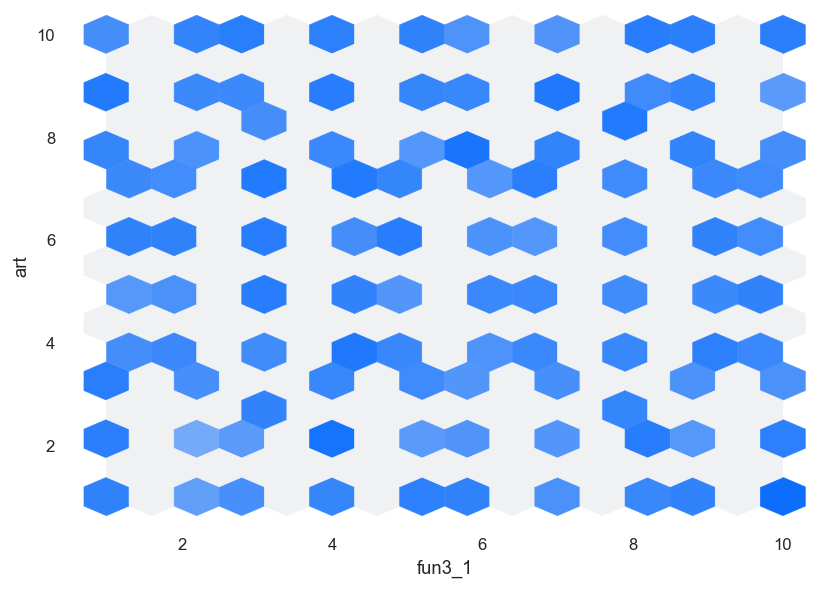

In [11]:
os.makedirs("../reports", exist_ok=True)

try:
    from ydata_profiling import ProfileReport
except:
    from pandas_profiling import ProfileReport

profile = ProfileReport(
    dfc,
    title="Speed Dating — Exploración",
    explorative=True
)

profile.to_file("../reports/pandas_profiling.html")

print("✅ Reporte guardado")
profile.to_notebook_iframe()

### 3.5 Distribución de la variable objetivo

OSError: [Errno 22] Invalid argument: '../reports/distribucion_target.png'

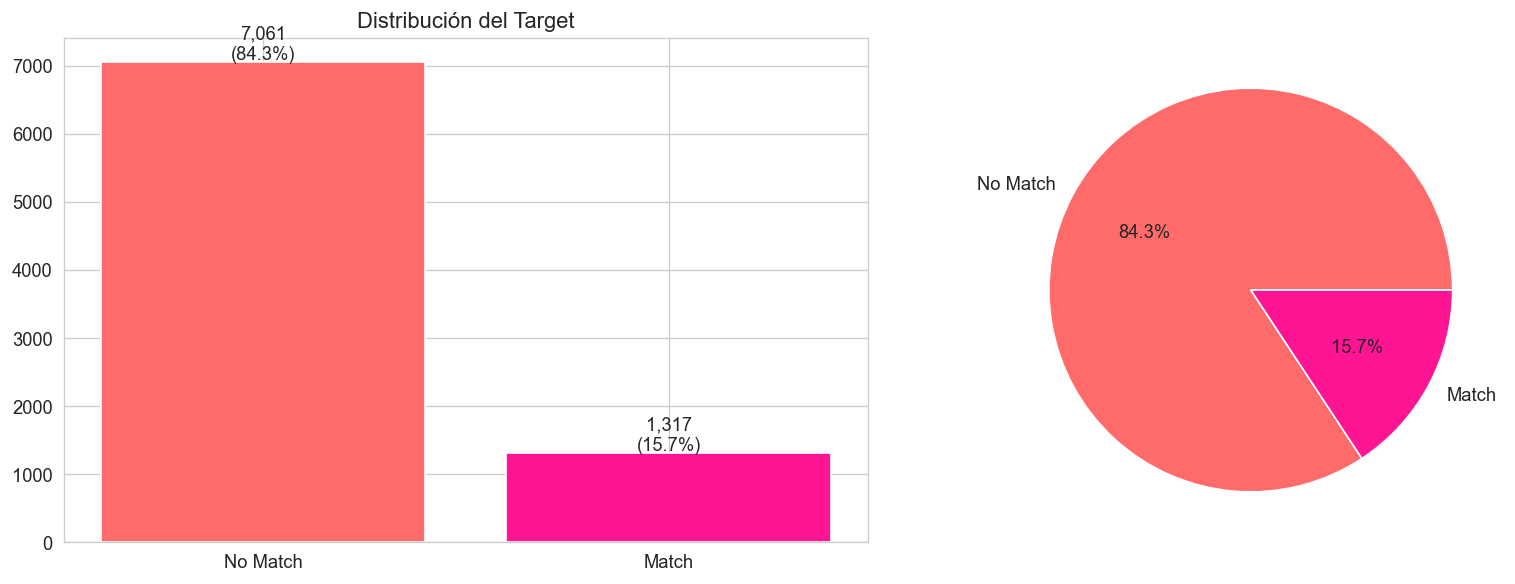

In [8]:
mc = dfc["match"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

colores = [PALETTE["negativo"], PALETTE["primario"]]

bars = axes[0].bar(
    ["No Match","Match"],
    mc.values,
    color=colores
)

axes[0].set_title("Distribución del Target")

for bar, val in zip(bars, mc.values):
    axes[0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+30,
        f"{val:,}\n({val/len(dfc)*100:.1f}%)",
        ha="center"
    )

axes[1].pie(
    mc.values,
    labels=["No Match","Match"],
    colors=colores,
    autopct="%1.1f%%"
)

plt.tight_layout()
plt.savefig("../reports/distribucion_target.png", dpi=150)
plt.show()

print(f"Ratio desbalance: {mc[0]/mc[1]:.1f}:1")

### 3.6 Estadística descriptiva

In [9]:
feats = [c for c in dfc.columns if c != "match"]

desc = dfc[feats].describe().T.round(2)

desc["nulos"] = dfc[feats].isnull().sum()

desc["pct_nulos"] = (
    dfc[feats].isnull().sum()/len(dfc)*100
).round(1)

print(desc[["count","mean","std","min","max","nulos","pct_nulos"]])

           count      mean       std      min       max  nulos  pct_nulos
gender    8378.0      0.50      0.50      0.0       1.0      0        0.0
age       8378.0     31.18      7.78     18.0      44.0      0        0.0
age_o     8378.0     31.12      7.74     18.0      44.0      0        0.0
race      8378.0      3.53      1.70      1.0       6.0      0        0.0
race_o    8378.0      3.47      1.70      1.0       6.0      0        0.0
samerace  8378.0      0.17      0.37      0.0       1.0      0        0.0
imprace   8378.0      5.51      2.87      1.0      10.0      0        0.0
goal      8378.0      3.49      1.72      1.0       6.0      0        0.0
date      8378.0      3.99      2.01      1.0       7.0      0        0.0
go_out    8378.0      4.01      1.97      1.0       7.0      0        0.0
field_cd  8378.0      9.55      5.17      1.0      18.0      0        0.0
career_c  8378.0      8.99      4.89      1.0      17.0      0        0.0
income    8378.0  83836.40  37512.21  

### 3.7 Limpieza de valores nulos

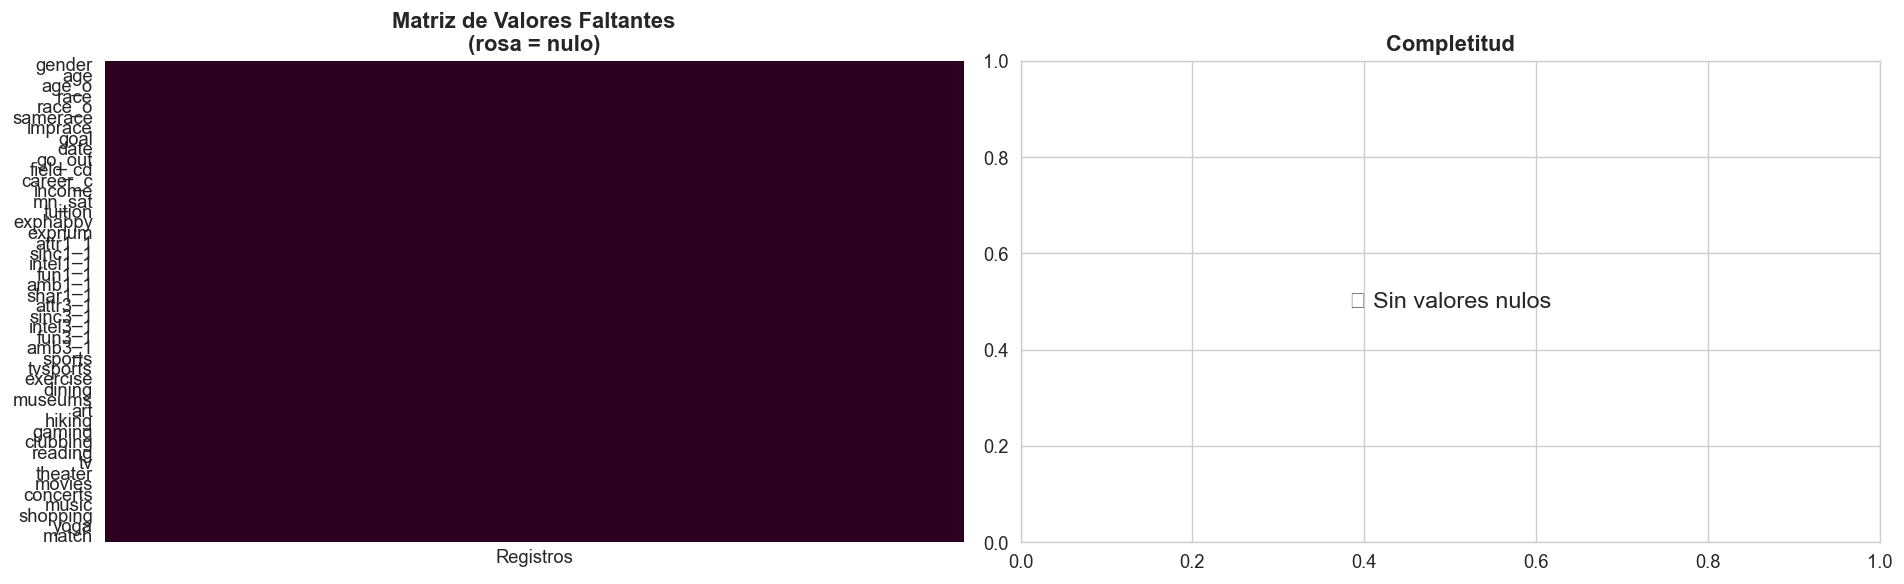

Variables con nulos: 0


In [10]:
# Análisis de nulos sin missingno
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular nulos
nulos = dfc.isnull().sum()
pct_nulos = (nulos / len(dfc) * 100).round(1)
df_nulos = pd.DataFrame({"Nulos": nulos, "Porcentaje": pct_nulos})
df_nulos = df_nulos[df_nulos["Nulos"] > 0].sort_values("Porcentaje", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap de nulos
nulos_heatmap = dfc.isnull().astype(int)
sns.heatmap(nulos_heatmap.T, cmap=["#2d0022","#FF1493"],
            ax=axes[0], cbar=False, yticklabels=True, xticklabels=False)
axes[0].set_title("Matriz de Valores Faltantes\n(rosa = nulo)", fontweight="bold")
axes[0].set_xlabel("Registros")

# Barras de completitud
if len(df_nulos) > 0:
    axes[1].barh(df_nulos.index, df_nulos["Porcentaje"],
                 color="#FF1493", edgecolor="white")
    axes[1].set_xlabel("% Valores Faltantes")
    axes[1].set_title("Variables con Nulos", fontweight="bold")
    for i, (idx, row) in enumerate(df_nulos.iterrows()):
        axes[1].text(row["Porcentaje"] + 0.3, i,
                     f"{row['Porcentaje']}%", va="center", fontsize=9)
else:
    axes[1].text(0.5, 0.5, "✅ Sin valores nulos",
                 ha="center", va="center", fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title("Completitud", fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/nulos.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Variables con nulos: {len(df_nulos)}")
if len(df_nulos) > 0:
    print(df_nulos.to_string())

### 3.8 Detección y tratamiento de valores atípicos (Winsorizing)

In [11]:
EXCLUIR_WINSOR = [
    "match","gender","race","race_o","samerace",
    "goal","date","go_out","field_cd","career_c"
]

cols_winsor = [
    c for c in dfc.select_dtypes(include=[np.number]).columns
    if c not in EXCLUIR_WINSOR
]

for col in cols_winsor:
    p5 = dfc[col].quantile(0.05)
    p95 = dfc[col].quantile(0.95)

    dfc[col] = dfc[col].clip(lower=p5, upper=p95)

for col in ["age","age_o"]:
    if col in dfc.columns:
        dfc = dfc[(dfc[col] >= 18) & (dfc[col] <= 45)]

print(f"Shape tras winsorizing: {dfc.shape}")

Shape tras winsorizing: (8378, 46)


### 3.9 Análisis de correlaciones — Redundancia e irrelevancia

Variables antes del análisis: 45


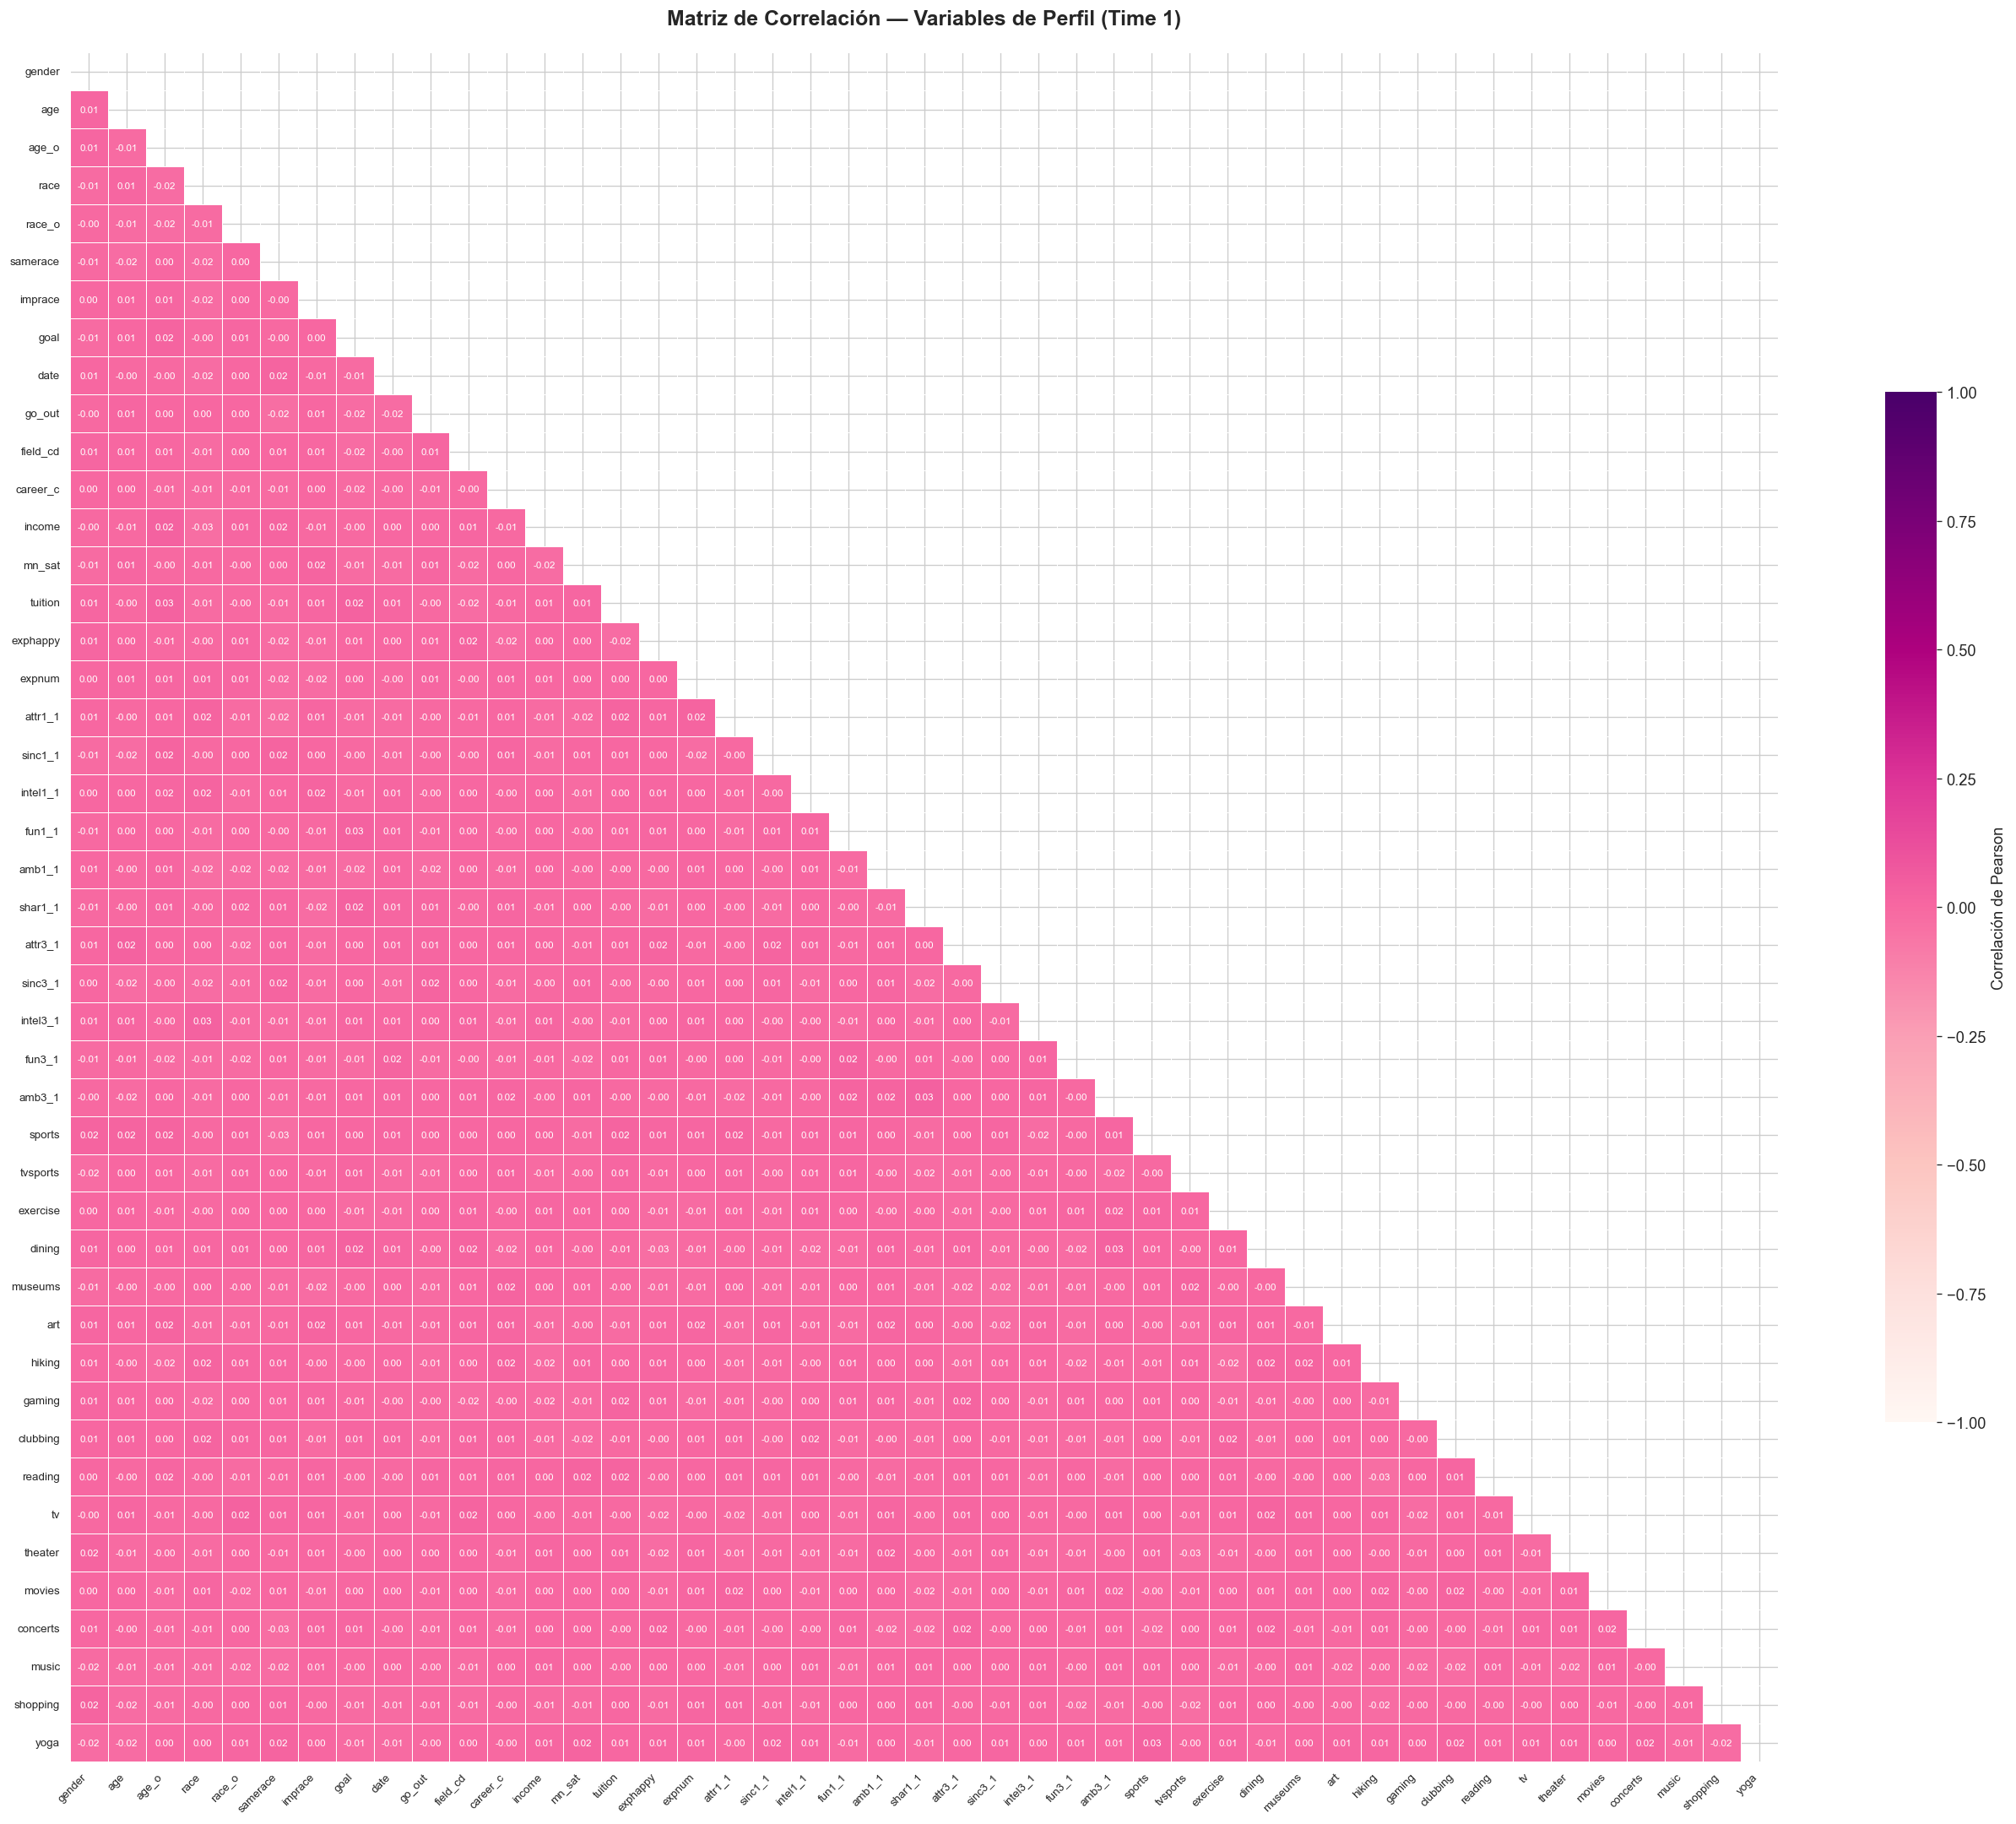

=== PASO 1: REDUNDANCIA (|corr| > 0.80 entre variables) ===
  Ningún par supera 0.80 — sin eliminaciones por redundancia

=== PASO 2: IRRELEVANCIA (|corr con match|) — SOLO INFORMATIVO ===
  Variables con |corr| < 0.05: 45
  Variables con |corr| ≥ 0.05: 0

  NOTA: En variables de perfil (Time 1), correlaciones bajas
  individualmente son normales. El poder predictivo es en conjunto.
  NO se elimina ninguna variable por este criterio.


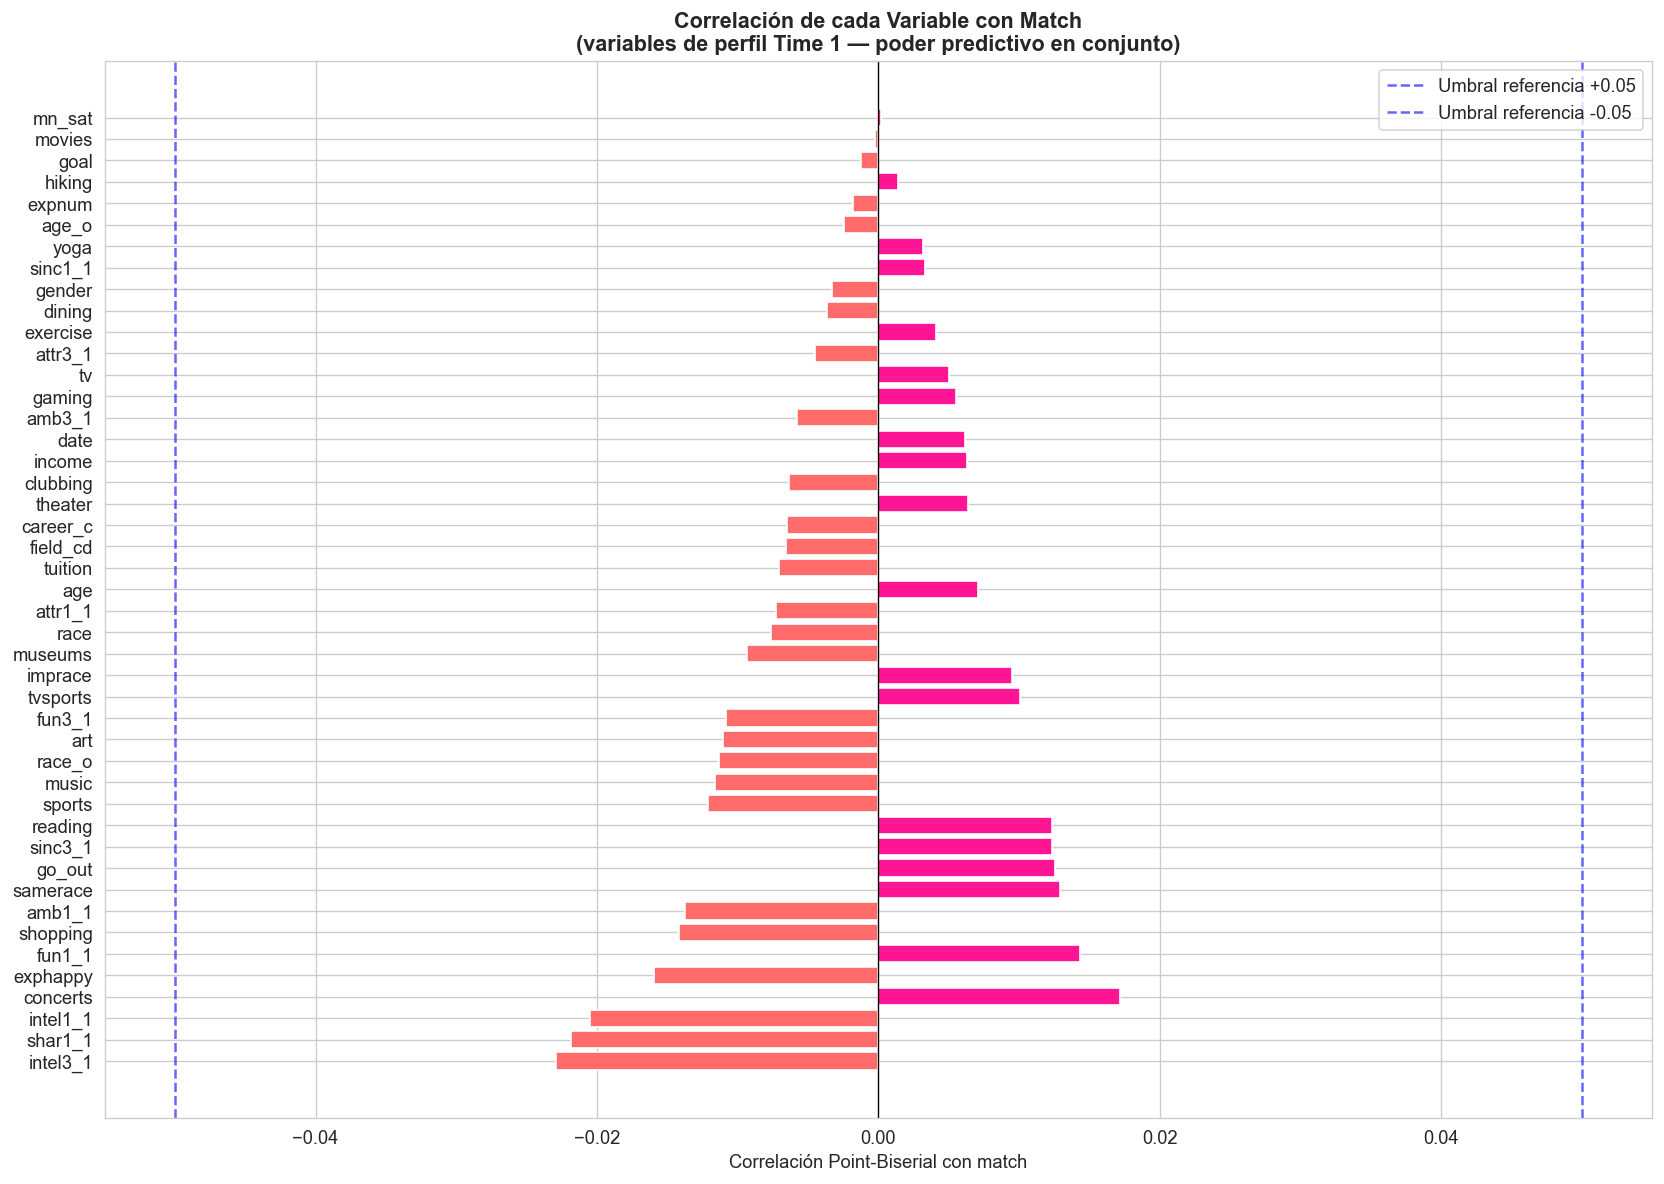


=== RESUMEN ===
Variables iniciales:           45
Eliminadas por redundancia:    0
Eliminadas por irrelevancia:   0 (umbral no aplicado — ver nota)
Variables finales para modelo: 45

Top 10 más correlacionadas con match:
          correlacion         p  abs_corr
variable                                 
intel3_1    -0.022928  0.035853  0.022928
shar1_1     -0.021845  0.045560  0.021845
intel1_1    -0.020472  0.060960  0.020472
concerts     0.017131  0.116905  0.017131
exphappy    -0.015965  0.143970  0.015965
fun1_1       0.014352  0.188992  0.014352
shopping    -0.014200  0.193741  0.014200
amb1_1      -0.013715  0.209388  0.013715
samerace     0.012893  0.238018  0.012893
go_out       0.012528  0.251542  0.012528


In [ ]:
# ============================================================
# ANÁLISIS DE CORRELACIONES
# Redundante: |corr entre variables| > 0.80 → eliminar una
# Irrelevante: |corr con match| < 0.05 → solo documentar, NO eliminar
# NOTA: Variables de perfil (Time 1) tienen baja correlación individual
# con match. Esto es normal — su poder predictivo es en conjunto.
# ============================================================
from scipy import stats

feats = [c for c in dfc.columns if c != "match"]
print(f"Variables antes del análisis: {len(feats)}")
corr_matrix = dfc[feats].corr()

# ── Heatmap triangular ──────────────────────────────────────
plt.figure(figsize=(22, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdPu",
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink": 0.6, "label": "Correlación de Pearson"}
)
plt.title("Matriz de Correlación — Variables de Perfil (Time 1)",
          fontsize=15, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("../reports/correlaciones_redundancia.png", dpi=150, bbox_inches="tight")
plt.show()

# ── REDUNDANCIA ─────────────────────────────────────────────
print("PASO 1: REDUNDANCIA (|corr| > 0.80 entre variables)")
cols_eliminar_red = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.80:
            ci = corr_matrix.columns[i]
            cj = corr_matrix.columns[j]
            r_ci = abs(stats.pointbiserialr(dfc["match"], dfc[ci])[0])
            r_cj = abs(stats.pointbiserialr(dfc["match"], dfc[cj])[0])
            eliminada = ci if r_ci < r_cj else cj
            cols_eliminar_red.add(eliminada)
            print(f"  {ci} ↔ {cj}: r={corr_matrix.iloc[i,j]:.3f} → eliminar '{eliminada}'")

if cols_eliminar_red:
    dfc.drop(columns=list(cols_eliminar_red), inplace=True, errors="ignore")
    print(f"  Eliminadas: {cols_eliminar_red}")
else:
    print("  Ningún par supera 0.80 — sin eliminaciones por redundancia")

# ── IRRELEVANCIA — solo documentar ──────────────────────────
print("\nPASO 2: IRRELEVANCIA (|corr con match|)")
feats2 = [c for c in dfc.columns if c != "match"]

corr_list = []
for col in feats2:
    r, p = stats.pointbiserialr(dfc["match"], dfc[col])
    corr_list.append({"variable": col, "correlacion": r, "p": p})

df_corr = pd.DataFrame(corr_list).set_index("variable")
df_corr["abs_corr"] = df_corr["correlacion"].abs()
df_corr = df_corr.sort_values("abs_corr", ascending=False)

# Clasificar por fuerza de correlación
bajo_umbral = df_corr[df_corr["abs_corr"] < 0.05]
print(f"  Variables con |corr| < 0.05: {len(bajo_umbral)}")
print(f"  Variables con |corr| ≥ 0.05: {len(df_corr) - len(bajo_umbral)}")
print(f"\n  NOTA: En variables de perfil (Time 1), correlaciones bajas")
print(f"  individualmente son normales. El poder predictivo es en conjunto.")
print(f"  NO se elimina ninguna variable por este criterio.")

# ── Gráfico barras correlación con match ────────────────────
plt.figure(figsize=(14, 10))
colores_bar = ["#FF1493" if v > 0 else "#FF6B6B" for v in df_corr["correlacion"]]
plt.barh(df_corr.index, df_corr["correlacion"], color=colores_bar, edgecolor="white")
plt.axvline(x=0.05,  color="blue", linestyle="--", alpha=0.6, label="Umbral referencia +0.05")
plt.axvline(x=-0.05, color="blue", linestyle="--", alpha=0.6, label="Umbral referencia -0.05")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Correlación Point-Biserial con match", fontsize=11)
plt.title("Correlación de cada Variable con Match\n(variables de perfil Time 1 — poder predictivo en conjunto)",
          fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/correlaciones_target.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Resumen ──────────────────────────────────────────────────
print("\nRESUMEN")
print(f"Variables iniciales:           {len(feats)}")
print(f"Eliminadas por redundancia:    {len(cols_eliminar_red)}")
print(f"Eliminadas por irrelevancia:   0 (umbral no aplicado — ver nota)")
print(f"Variables finales para modelo: {dfc.shape[1]-1}")
print(f"\nTop 10 más correlacionadas con match:")
print(df_corr.head(10).to_string())

### 3.10 Ingeniería de características

In [13]:
if "age" in dfc.columns and "age_o" in dfc.columns:
    dfc["age_diff"] = abs(dfc["age"] - dfc["age_o"])

pref_cols = [
    c for c in [
        "attr1_1","sinc1_1","intel1_1",
        "fun1_1","amb1_1","shar1_1"
    ]
    if c in dfc.columns
]

if pref_cols:
    dfc["pref_score"] = dfc[pref_cols].mean(axis=1)

self_cols = [
    c for c in [
        "attr3_1","sinc3_1","intel3_1",
        "fun3_1","amb3_1"
    ]
    if c in dfc.columns
]

if self_cols:
    dfc["self_score"] = dfc[self_cols].mean(axis=1)

print(f"Shape final: {dfc.shape}")

Shape final: (8378, 49)


### 3.11 Split → Scaler → SMOTE → Guardar

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

os.makedirs("../data", exist_ok=True)
os.makedirs("../models", exist_ok=True)

X = dfc.drop(columns=["match"])
y = dfc["match"]

feature_names = list(X.columns)

X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=feature_names
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=feature_names
)

smote = SMOTE(random_state=42, k_neighbors=5)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled,
    y_train_raw
)

X_train_bal = pd.DataFrame(
    X_train_bal,
    columns=feature_names
)

LEAKAGE = [
    'dec','dec_o','like','prob','attr','sinc','intel','fun',
    'amb','shar','attr_o','sinc_o','intel_o','fun_o','amb_o',
    'shar_o','int_corr','met','like_o','prob_o'
]

for col in LEAKAGE:
    assert col not in X_train_bal.columns, f"LEAKAGE: {col}"

assert abs(y_train_bal.mean() - 0.5) < 0.01, "SMOTE no aplicado"
assert 0.14 < y_test.mean() < 0.20, "y_test corrupto"
assert X_train_scaled.mean().mean() < 0.1, "Scaler mal aplicado"

X_train_bal.to_csv("../data/X_train.csv", index=False)
X_test_scaled.to_csv("../data/X_test.csv", index=False)

pd.Series(y_train_bal, name="match").to_csv(
    "../data/y_train.csv",
    index=False
)

pd.Series(y_test, name="match").to_csv(
    "../data/y_test.csv",
    index=False
)

with open("../data/feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

with open("../data/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(" NOTEBOOK 1 COMPLETADO")

✅ NOTEBOOK 1 COMPLETADO
